# Why is the height $h$ — and not the side $a$ — used in $\text{Area} = \tfrac{1}{2} c h$?

Your question, distilled:

> *Tilting (rotating) side $a$ doesn't change its length, so why does it change the area? Why can't I just use $a$ as the height?*

The answer hides a subtle confusion between **two different operations** that look similar but aren't:

| Operation | What stays the same | What changes | Area? |
|---|---|---|---|
| **Rotate** side $a$ around $B$ | $\lvert a\rvert$ (the stick length) | The height $h$, position of $C$ | **Changes** |
| **Shear** the apex sideways | The height $h$ | $\lvert a\rvert$ (stick stretches) | **Stays the same** |

Your intuition *“sliding the top doesn't change area”* is the **shear** — and it's correct! But it's not the same as rotating. The notebook below shows both, side-by-side, so you can see the difference.

We'll go through three blocks, then end with a slider you can drag.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Arc, FancyArrowPatch

plt.rcParams['figure.dpi'] = 110

## Block 1 — Look closely: $h$ and $a$ are **two different lines**

In the original picture the side $a$ is *slanted*. The height $h$ is the **vertical drop** from the apex $C$ straight down to the base.

Trigonometry on the small right‑triangle $C\,D\,B$ tells us exactly how they relate:

$$\boxed{\; h = a \sin\beta \;}$$

Because $\sin\beta < 1$ whenever $\beta < 90°$, the height $h$ is **always shorter** than the slanted side $a$. They can't be the same number — except in the one special case $\beta = 90°$.

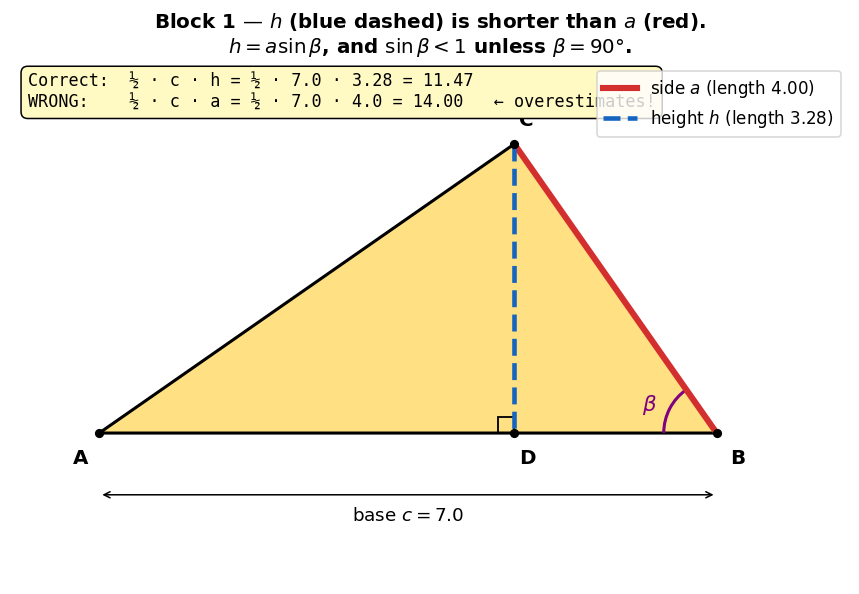

In [2]:
# === BLOCK 1: The reference triangle, with h and a both shown ===

def draw_reference_triangle(ax, beta_deg=55, a_len=4.0, c_len=7.0):
    beta = np.radians(beta_deg)
    A = np.array([0.0, 0.0])
    B = np.array([c_len, 0.0])
    # C is reached from B by going at angle (180° - beta) from positive x-axis
    C = B + a_len * np.array([np.cos(np.pi - beta), np.sin(np.pi - beta)])
    D = np.array([C[0], 0.0])  # foot of the perpendicular
    h = C[1]

    # Triangle
    tri = plt.Polygon([A, B, C], closed=True, fc='#FFE082', ec='black', lw=2)
    ax.add_patch(tri)

    # Side a (slanted) — emphasised in red
    ax.plot([B[0], C[0]], [B[1], C[1]], color='#D32F2F', lw=4, label=f'side $a$ (length {a_len:.2f})')
    # Height h — emphasised in blue, dashed
    ax.plot([C[0], D[0]], [C[1], D[1]], color='#1565C0', lw=3, ls='--', label=f'height $h$ (length {h:.2f})')

    # Right-angle marker at D
    sq = 0.18
    ax.add_patch(patches.Rectangle((D[0]-sq, 0), sq, sq, fc='none', ec='black', lw=1.2))

    # Vertices and labels
    for P, name, off in [(A, 'A', (-0.3, -0.35)), (B, 'B', (0.15, -0.35)),
                          (C, 'C', (0.05, 0.2)), (D, 'D', (0.05, -0.35))]:
        ax.plot(*P, 'ko', ms=5)
        ax.text(P[0]+off[0], P[1]+off[1], name, fontsize=13, fontweight='bold')

    # Beta arc
    arc = Arc(B, 1.2, 1.2, angle=0, theta1=180-beta_deg, theta2=180, color='purple', lw=2)
    ax.add_patch(arc)
    ax.text(B[0]-0.85, 0.25, r'$\beta$', color='purple', fontsize=14, fontweight='bold')

    # Base
    ax.annotate('', xy=(B[0], -0.7), xytext=(A[0], -0.7),
                arrowprops=dict(arrowstyle='<->', color='black'))
    ax.text(c_len/2, -1.0, f'base $c = {c_len}$', ha='center', fontsize=12)

    return h, a_len, c_len

fig, ax = plt.subplots(figsize=(9, 5.5))
h, a_len, c_len = draw_reference_triangle(ax, beta_deg=55)

ax.set_xlim(-1, 8.5); ax.set_ylim(-1.7, 4.2)
ax.set_aspect('equal'); ax.axis('off')

# Compare formulas
true_area = 0.5 * c_len * h
wrong_area = 0.5 * c_len * a_len
ax.text(0.02, 0.98,
        f'Correct:  ½ · c · h = ½ · {c_len} · {h:.2f} = {true_area:.2f}\n'
        f'WRONG:    ½ · c · a = ½ · {c_len} · {a_len} = {wrong_area:.2f}   ← overestimates!',
        transform=ax.transAxes, fontsize=11, va='top', family='monospace',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

ax.legend(loc='upper right', fontsize=11)
ax.set_title('Block 1 — $h$ (blue dashed) is shorter than $a$ (red).\n'
             '$h = a\\sin\\beta$, and $\\sin\\beta < 1$ unless $\\beta = 90°$.',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Block 2 — The ladder demo: rotate side $a$ and watch $C$ drop

Pin side $a$ at vertex $B$. Keep its **length the same** (it's a rigid stick). Now rotate it: from upright ($90°$) all the way down toward the base.

- **The stick's length never changes.** ✅ (your intuition was right about that)
- **But the apex $C$ physically gets lower as $\beta$ shrinks.** ← this is what changes the area
- **The height $h = a\sin\beta$ shrinks with it.**
- **So the area shrinks.**

The plot below shows the same stick at four angles, plus a graph of how the area shrinks as the angle decreases.

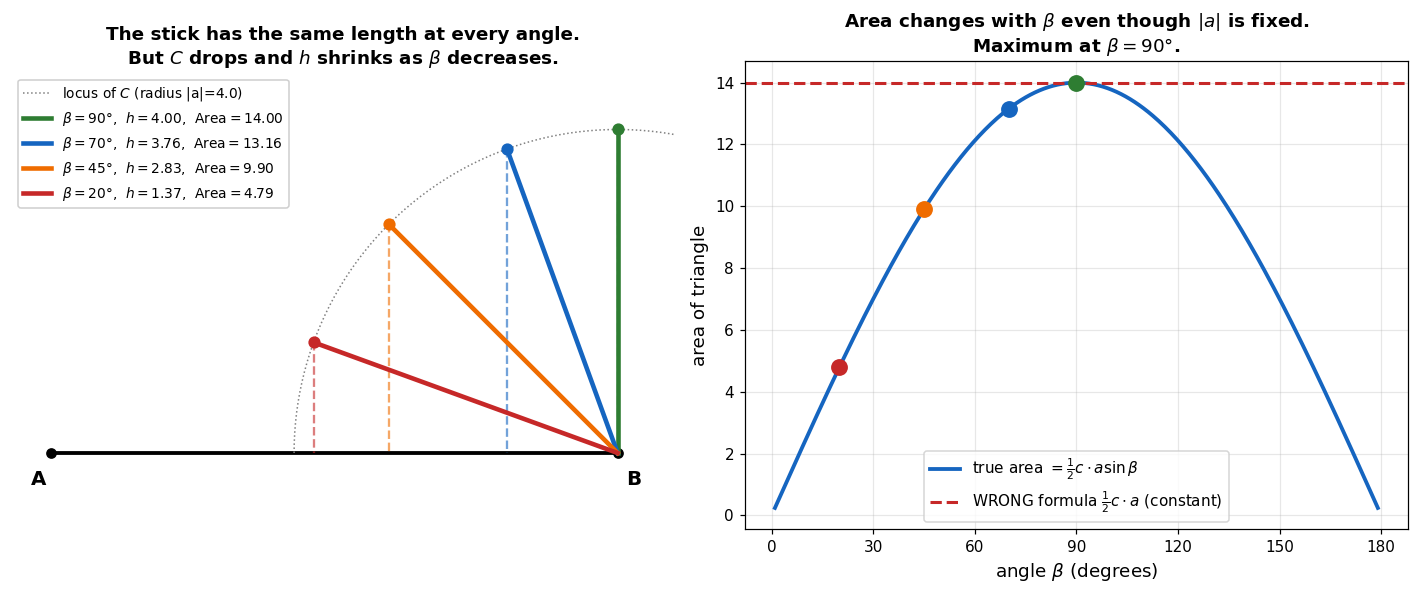

In [ ]:
# === BLOCK 2: Rotate side a around B at four angles, then plot Area(beta) ===

a_len = 4.0
c_len = 7.0
angles_deg = [90, 70, 45, 20]
colours = ['#2E7D32', '#1565C0', '#EF6C00', '#C62828']

fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# --- LEFT: overlay all four ladder positions, sharing base AB ---
A = np.array([0.0, 0.0])
B = np.array([c_len, 0.0])
ax1.plot([A[0], B[0]], [A[1], B[1]], color='black', lw=2.5)
ax1.plot(*A, 'ko', ms=6); ax1.plot(*B, 'ko', ms=6)
ax1.text(A[0]-0.25, -0.4, 'A', fontsize=13, fontweight='bold')
ax1.text(B[0]+0.1, -0.4, 'B', fontsize=13, fontweight='bold')

# circle showing the locus of C as the stick rotates
theta_circ = np.linspace(0, np.pi, 200)
ax1.plot(B[0] + a_len*np.cos(np.pi - theta_circ),
         a_len*np.sin(np.pi - theta_circ),
         color='gray', ls=':', lw=1, label=f'locus of $C$ (radius |a|={a_len})')

for beta_deg, col in zip(angles_deg, colours):
    beta = np.radians(beta_deg)
    C = B + a_len * np.array([np.cos(np.pi - beta), np.sin(np.pi - beta)])
    h = C[1]
    area = 0.5 * c_len * h
    # the stick (side a)
    ax1.plot([B[0], C[0]], [B[1], C[1]], color=col, lw=3,
             label=f'$\\beta={beta_deg}°$,  $h={h:.2f}$,  Area$={area:.2f}$')
    # vertical drop (height)
    ax1.plot([C[0], C[0]], [C[1], 0], color=col, lw=1.5, ls='--', alpha=0.6)
    ax1.plot(*C, 'o', color=col, ms=7)

ax1.set_xlim(-0.5, c_len+0.7); ax1.set_ylim(-0.8, a_len+0.7)
ax1.set_aspect('equal'); ax1.axis('off')
ax1.set_title('The stick has the same length at every angle.\n'
              'But $C$ drops and $h$ shrinks as $\\beta$ decreases.',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.95)

# --- RIGHT: plot Area vs beta ---
betas = np.linspace(1, 179, 400)
heights = a_len * np.sin(np.radians(betas))
areas = 0.5 * c_len * heights
ax2.plot(betas, areas, color='#1565C0', lw=2.5, label=r'true area $= \frac{1}{2} c \cdot a\sin\beta$')
ax2.axhline(0.5*c_len*a_len, color='#C62828', lw=2, ls='--',
            label=r'WRONG formula $\frac{1}{2} c \cdot a$ (constant)')
for beta_deg, col in zip(angles_deg, colours):
    h = a_len * np.sin(np.radians(beta_deg))
    ax2.plot(beta_deg, 0.5*c_len*h, 'o', color=col, ms=10, zorder=5)
ax2.set_xlabel(r'angle $\beta$ (degrees)', fontsize=12)
ax2.set_ylabel('area of triangle', fontsize=12)
ax2.set_title('Area changes with $\\beta$ even though $|a|$ is fixed.\n'
              'Maximum at $\\beta = 90°$.', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower center', fontsize=10)
ax2.set_xticks([0, 30, 60, 90, 120, 150, 180])

plt.tight_layout(); plt.show()

### The clincher: rotating $a$ ≠ shearing the triangle

This is, I think, the *real* source of your confusion. There are **two ways** to "move the top point sideways", and they have *opposite* effects on length and area:

1. **Rotate** side $a$ (Block 2 above): $|a|$ stays fixed, $h$ shrinks, **area shrinks**.
2. **Shear** the triangle: $h$ stays fixed (we slide $C$ horizontally), $|a|$ stretches, **area stays the same**.

Your gut feeling — *“sliding the top doesn't change area”* — describes shearing. That's the *deck-of-cards* / *Cavalieri* picture. The plot below puts both side-by-side so the difference is unmissable.

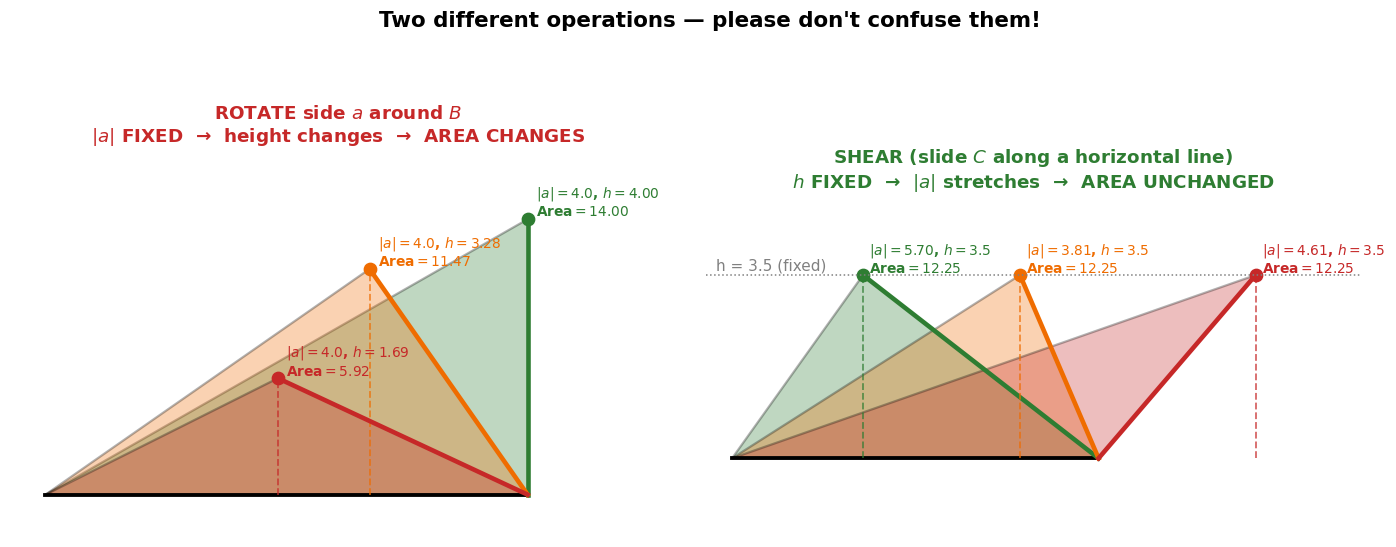

In [ ]:
# === Rotate vs Shear: two side-by-side panels ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
c_len = 7.0

# --- LEFT: ROTATE  (|a| fixed, h changes) ---
ax = axes[0]
A = np.array([0.0, 0.0]); B = np.array([c_len, 0.0])
a_len = 4.0
ax.plot([A[0], B[0]], [A[1], B[1]], 'k', lw=2.5)
for beta_deg, col, alpha in [(90, '#2E7D32', 0.95), (55, '#EF6C00', 0.85), (25, '#C62828', 0.75)]:
    beta = np.radians(beta_deg)
    C = B + a_len * np.array([np.cos(np.pi - beta), np.sin(np.pi - beta)])
    h = C[1]; area = 0.5*c_len*h
    tri = plt.Polygon([A, B, C], closed=True, fc=col, ec='black', lw=1.5, alpha=0.30)
    ax.add_patch(tri)
    ax.plot([B[0], C[0]], [B[1], C[1]], color=col, lw=3)
    ax.plot([C[0], C[0]], [0, C[1]], color=col, lw=1.2, ls='--', alpha=0.7)
    ax.plot(*C, 'o', color=col, ms=8)
    ax.text(C[0]+0.12, C[1]+0.05, f'$|a|={a_len}$, $h={h:.2f}$\nArea$={area:.2f}$',
            fontsize=9, color=col, fontweight='bold')
ax.set_xlim(-0.5, 9); ax.set_ylim(-0.6, 5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('ROTATE side $a$ around $B$\n'
             '$|a|$ FIXED  →  height changes  →  AREA CHANGES',
             fontsize=12, fontweight='bold', color='#C62828')

# --- RIGHT: SHEAR (h fixed, |a| changes) ---
ax = axes[1]
ax.plot([A[0], B[0]], [A[1], B[1]], 'k', lw=2.5)
h_fixed = 3.5
# pick C-x values that are NOT symmetric around B (=7), so each |a| is distinct
for cx, col in [(2.5, '#2E7D32'), (5.5, '#EF6C00'), (10.0, '#C62828')]:
    C = np.array([cx, h_fixed])
    a_curr = np.linalg.norm(C - B)
    area = 0.5 * c_len * h_fixed
    tri = plt.Polygon([A, B, C], closed=True, fc=col, ec='black', lw=1.5, alpha=0.30)
    ax.add_patch(tri)
    ax.plot([B[0], C[0]], [B[1], C[1]], color=col, lw=3)
    ax.plot([C[0], C[0]], [0, C[1]], color=col, lw=1.2, ls='--', alpha=0.7)
    ax.plot(*C, 'o', color=col, ms=8)
    ax.text(C[0]+0.12, C[1]+0.05, f'$|a|={a_curr:.2f}$, $h={h_fixed}$\nArea$={area:.2f}$',
            fontsize=9, color=col, fontweight='bold')
# horizontal guide showing constant height
ax.axhline(h_fixed, color='gray', ls=':', lw=1)
ax.text(-0.3, h_fixed+0.1, f'h = {h_fixed} (fixed)', fontsize=10, color='gray')
ax.set_xlim(-0.5, 12); ax.set_ylim(-0.6, 5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('SHEAR (slide $C$ along a horizontal line)\n'
             '$h$ FIXED  →  $|a|$ stretches  →  AREA UNCHANGED',
             fontsize=12, fontweight='bold', color='#2E7D32')

plt.suptitle('Two different operations — please don\'t confuse them!',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Block 3 — At $\beta = 90°$, side $a$ **is** the height (and the area is maximal)

There is exactly one moment during the rotation where you *can* legitimately write $\text{Area} = \tfrac{1}{2} c \cdot a$: when the stick is vertical. Then $\sin\beta = \sin 90° = 1$ and $h = a \cdot 1 = a$.

It is also, unsurprisingly, the angle that gives the **largest possible area** for the given $c$ and $|a|$. Any tilt away from vertical pulls the apex closer to the ground.

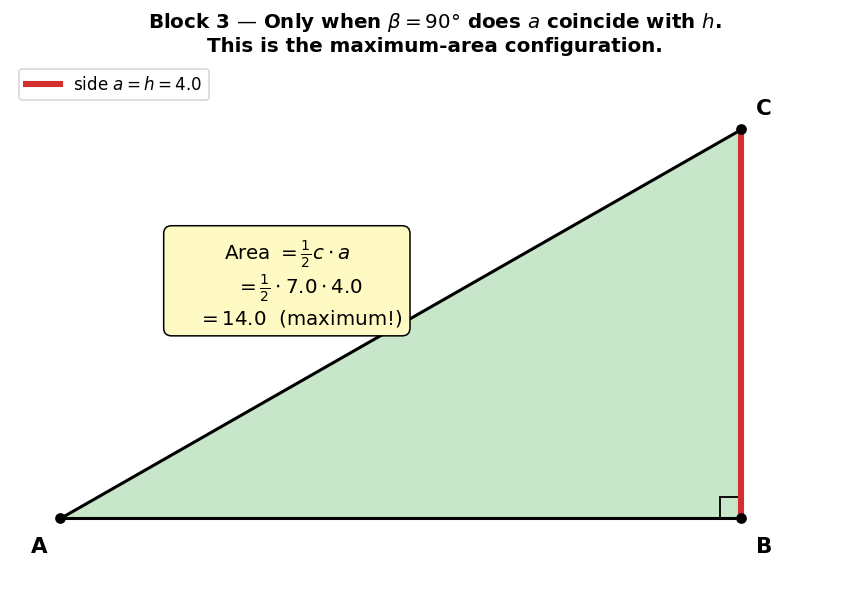

In [ ]:
# === BLOCK 3: The 90° case — a IS the height ===

fig, ax = plt.subplots(figsize=(8, 5.5))
c_len, a_len = 7.0, 4.0
A = np.array([0.0, 0.0]); B = np.array([c_len, 0.0])
C = np.array([c_len, a_len])  # straight up from B

tri = plt.Polygon([A, B, C], closed=True, fc='#C8E6C9', ec='black', lw=2)
ax.add_patch(tri)
ax.plot([B[0], C[0]], [B[1], C[1]], color='#D32F2F', lw=4, label=f'side $a = h = {a_len}$')

# right-angle marker at B
sq = 0.22
ax.add_patch(patches.Rectangle((B[0]-sq, 0), sq, sq, fc='none', ec='black', lw=1.2))

for P, name, off in [(A, 'A', (-0.3, -0.35)), (B, 'B', (0.15, -0.35)), (C, 'C', (0.15, 0.15))]:
    ax.plot(*P, 'ko', ms=6)
    ax.text(P[0]+off[0], P[1]+off[1], name, fontsize=14, fontweight='bold')

area = 0.5 * c_len * a_len
ax.text(c_len/3, a_len/2,
        f'Area $= \\frac{{1}}{{2}} c \\cdot a$\n'
        f'    $= \\frac{{1}}{{2}} \\cdot {c_len} \\cdot {a_len}$\n'
        f'    $= {area}$  (maximum!)',
        fontsize=13, ha='center',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

ax.set_xlim(-0.5, c_len+1.2); ax.set_ylim(-0.8, a_len+0.7)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Block 3 — Only when $\\beta = 90°$ does $a$ coincide with $h$.\n'
             'This is the maximum-area configuration.',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout(); plt.show()

## Your “half a rectangle” intuition — rescued

You said:

> *imagine a full square, divide it in half — that's your triangle area. Squares and rectangles have lines perpendicular to the base.*

**That intuition is exactly right!** It just has to be applied carefully:

- The rectangle whose half is the triangle has dimensions **base × height = $c \times h$** — *not* $c \times a$.
- A box with sides $c$ and the slanted $a$ wouldn't be a rectangle at all; it would be a **parallelogram**, whose area is also $c \cdot h$ (not $c \cdot a$).

Watch:

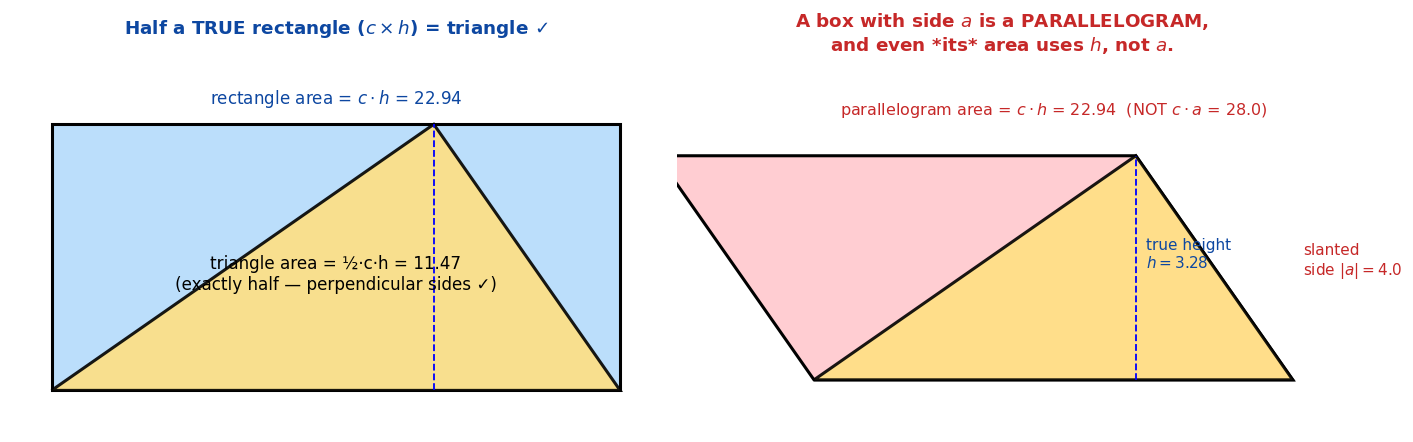

In [ ]:
# === Rectangle (c × h) halved → triangle.   Parallelogram (c × a) ≠ triangle's rectangle ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
c_len, a_len, beta_deg = 7.0, 4.0, 55
beta = np.radians(beta_deg)
A = np.array([0.0, 0.0]); B = np.array([c_len, 0.0])
C = B + a_len * np.array([np.cos(np.pi - beta), np.sin(np.pi - beta)])
h = C[1]

# --- LEFT: triangle inside its proper c × h rectangle ---
ax = axes[0]
rect = patches.Rectangle((0, 0), c_len, h, fc='#BBDEFB', ec='black', lw=2)
ax.add_patch(rect)
tri = plt.Polygon([A, B, C], closed=True, fc='#FFE082', ec='black', lw=2, alpha=0.9)
ax.add_patch(tri)
ax.plot([C[0], C[0]], [0, h], 'b--', lw=1.2)
ax.text(c_len/2, h+0.25, f'rectangle area = $c \\cdot h$ = {c_len*h:.2f}',
        ha='center', fontsize=11, color='#0D47A1')
ax.text(c_len/2, h/2-0.4, f'triangle area = ½·c·h = {0.5*c_len*h:.2f}\n(exactly half — perpendicular sides ✓)',
        ha='center', fontsize=11)
ax.set_xlim(-0.5, c_len+0.5); ax.set_ylim(-0.5, h+1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Half a TRUE rectangle ($c \\times h$) = triangle ✓',
             fontsize=12, fontweight='bold', color='#0D47A1')

# --- RIGHT: the would-be c × a 'box' is actually a parallelogram ---
ax = axes[1]
# parallelogram: A, B, C, A + (C-B)
P4 = A + (C - B)
para = plt.Polygon([A, B, C, P4], closed=True, fc='#FFCDD2', ec='black', lw=2)
ax.add_patch(para)
tri = plt.Polygon([A, B, C], closed=True, fc='#FFE082', ec='black', lw=2, alpha=0.9)
ax.add_patch(tri)
# show its real height vs. its slanted side
ax.plot([C[0], C[0]], [0, h], 'b--', lw=1.2)
ax.text(C[0]+0.15, h/2, f'true height\n$h={h:.2f}$', color='#0D47A1', fontsize=10)
ax.text(B[0]+0.15, (B[1]+C[1])/2-0.1, f'slanted\nside $|a|={a_len}$', color='#C62828', fontsize=10)
ax.text((A[0]+B[0])/2, h+0.6,
        f'parallelogram area = $c \\cdot h$ = {c_len*h:.2f}  (NOT $c\\cdot a$ = {c_len*a_len})',
        ha='center', fontsize=10.5, color='#C62828')
ax.set_xlim(-2, c_len+0.5); ax.set_ylim(-0.5, h+1.4)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('A box with side $a$ is a PARALLELOGRAM,\n'
             'and even *its* area uses $h$, not $a$.',
             fontsize=12, fontweight='bold', color='#C62828')

plt.tight_layout(); plt.show()

## Now play with it yourself

Drag the slider for $\beta$ below. Watch:

- the red stick (side $a$) keeps the **same length** at every angle,
- the blue dashed height $h$ shrinks and grows,
- the printed area follows $h$, not $a$.

*(If the slider doesn't appear, run `pip install ipywidgets` and re‑run the cell.)*

In [ ]:
from ipywidgets import interact, FloatSlider

def show(beta_deg=55.0, a_len=4.0, c_len=7.0):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    h, _, _ = draw_reference_triangle(ax, beta_deg=beta_deg, a_len=a_len, c_len=c_len)
    ax.set_xlim(-1.5, c_len+1.5)
    ax.set_ylim(-1.7, max(a_len, h) + 1.0)
    ax.set_aspect('equal'); ax.axis('off')

    true_area  = 0.5 * c_len * h
    wrong_area = 0.5 * c_len * a_len
    ax.text(0.02, 0.98,
            f'β = {beta_deg:5.1f}°,  sin β = {np.sin(np.radians(beta_deg)):.3f}\n'
            f'h  = a · sin β = {a_len} · {np.sin(np.radians(beta_deg)):.3f} = {h:.3f}\n'
            f'TRUE  area  = ½ · c · h = {true_area:.3f}\n'
            f'WRONG area  = ½ · c · a = {wrong_area:.3f}   '
            f'(over by {wrong_area - true_area:+.3f})',
            transform=ax.transAxes, va='top', family='monospace', fontsize=11,
            bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))
    ax.set_title('Drag β. The stick (red) keeps its length; the height (blue) does not.',
                 fontsize=12, fontweight='bold')
    plt.show()

interact(show,
         beta_deg=FloatSlider(min=5, max=175, step=1, value=55, description='β (deg)'),
         a_len   =FloatSlider(min=1, max=6,  step=0.5, value=4, description='|a|'),
         c_len   =FloatSlider(min=3, max=10, step=0.5, value=7, description='c'));

interactive(children=(FloatSlider(value=55.0, description='β (deg)', max=175.0, min=5.0, step=1.0), FloatSlide…

## One‑line summary

$$
\text{Area} \;=\; \tfrac{1}{2}\, c\, h \;=\; \tfrac{1}{2}\, c\, a\sin\beta
$$

- Use $h$ because area is built out of **vertical layers** (or equivalently, a perpendicular rectangle). The height counts the layers.
- Use $a$ **only** when $\beta = 90°$, because then — and only then — does the side coincide with the vertical drop.
- The formula $\tfrac{1}{2} c \cdot a$ would always *over*estimate the area for any tilted triangle, by the factor $\dfrac{1}{\sin\beta} \ge 1$.